In [37]:
import pyarrow.dataset as ds
import pyarrow.parquet as pq

import uproot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import glob

In [25]:
ROOT_FILE = (
    "/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/"
    "2026_04_27_with_Zmmg_SaS/variables/2022/rapidity/root/mc/"
    "GluGluHtoGG_M-125_2022preEE/"
    "output_GluGluHToGG_M125_13TeV_amcatnloFXFX_pythia8.root"
)
 
SUBDIR      = "DiphotonTree"
TREE_NAME   = "ggh_125_13TeV_RECO_rapidity_0p9_1p2_cat2"
BRANCH      = "rapidity"
OUTPUT_PNG  = "rapidity_distribution.png"


In [26]:
# ── Functions ──────────────────────────────────────────────────────────────────
 
def open_tree(filepath: str, subdir: str, tree_name: str) -> uproot.TTree:
    """Open a ROOT file and return the requested TTree from a subdirectory."""
    root_file = uproot.open(filepath)
    path = f"{subdir}/{tree_name}"
    tree = root_file[path]
    print(f"Opened tree  : {path}")
    print(f"Entries      : {tree.num_entries:,}")
    print(f"Available branches: {tree.keys()}")
    return tree
 
 
def extract_branch(tree: uproot.TTree, branch: str) -> np.ndarray:
    """Extract a single branch from a TTree as a numpy array."""
    data = tree[branch].array(library="np")
    print(f"\nBranch '{branch}': {len(data):,} entries, "
          f"range [{data.min():.4f}, {data.max():.4f}]")
    return data
 
 
def plot_rapidity(
    values: np.ndarray,
    branch: str = "rapidity",
    n_bins: int = 60,
    output: str = OUTPUT_PNG,
) -> None:
    """Plot a histogram of the rapidity distribution and save to disk."""
 
    fig, ax = plt.subplots(figsize=(8, 5))
 
    counts, edges, patches = ax.hist(
        values,
        bins=n_bins,
        range=(values.min(), values.max()),
        color="#e87722",
        edgecolor="white",
        linewidth=0.5,
        alpha=0.85,
    )
 
    # Styling
    ax.set_xlabel("Rapidity $y$", fontsize=13)
    ax.set_ylabel("Events / bin", fontsize=13)
    ax.set_title(
        r"Diphoton Rapidity — $gg \to H \to \gamma\gamma$, $M_H = 125\,\mathrm{GeV}$"
        "\n(2022 preEE, cat1, $0.9 < |y| < 1.2$)",
        fontsize=11,
        pad=10,
    )
 
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
 
    # Stats box
    stats_text = (
        f"Entries : {len(values):,}\n"
        f"Mean    : {values.mean():.4f}\n"
        f"Std dev : {values.std():.4f}"
    )
    ax.text(
        0.97, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7),
    )
 
    fig.tight_layout()
    # fig.savefig(output, dpi=150)
    print(f"\nPlot saved to: {output}")
    plt.show()


Opened tree  : DiphotonTree/ggh_125_13TeV_RECO_rapidity_0p9_1p2_cat2
Entries      : 22,818
Available branches: ['AbsPhiEtaStar', 'BeamSpot_sigmaZ', 'BeamSpot_sigmaZError', 'CosThetaStarCS', 'DEtaJ0J1H', 'DPhiHJ0', 'DPhiHJ0J1', 'DPhiJ0J1', 'DYHJ0', 'DYJ0J1', 'EtaJ0J1', 'GenCosThetaStarCS', 'GenDEtaJ0J1H', 'GenDPhiHJ0', 'GenDPhiHJ0J1', 'GenDPhiJ0J1', 'GenDYHJ0', 'GenDYJ0J1', 'GenEtaJ0J1', 'GenMassJ0J1', 'GenNBJet', 'GenNJ', 'GenNJ_pt30_absEta2p5', 'GenPTH', 'GenPTJ0', 'GenPTJ1', 'GenPhiEtaStar', 'GenTauJC', 'GenYH', 'GenYJ0', 'GenYJ1', 'HTXS_Higgs_pt', 'HTXS_Higgs_y', 'HTXS_njets30', 'HTXS_stage_0', 'MassJ0J1', 'NJ', 'NJ_pt30_absEta2p5', 'PTJ0', 'PTJ1', 'PhiEtaStar', 'TauJC', 'TruthPTH', 'TruthYH', 'YJ0', 'YJ1', 'charge', 'dZ', 'eta', 'event', 'fiducialClassicalFlag', 'fiducialGeometricFlag', 'first_jet_eta', 'first_jet_mass', 'first_jet_phi', 'fixedGridRhoAll', 'genWeight', 'gen_first_jet_eta', 'gen_first_jet_mass', 'gen_first_jet_phi', 'gen_second_jet_eta', 'gen_second_jet_mass', 'gen_

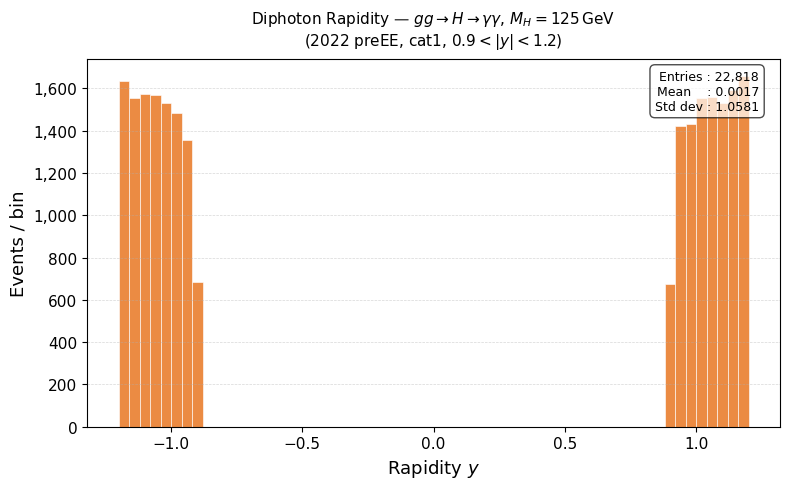

In [27]:
tree   = open_tree(ROOT_FILE, SUBDIR, TREE_NAME)
values = extract_branch(tree, BRANCH)
plot_rapidity(values, branch=BRANCH)

In [80]:
# Ok, now compare with the expected cuts
path = '/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2026_04_27_with_Zmmg_SaS/mc/2024/GluGluHtoGG_M-125_2024/nominal'

dataset = ds.dataset(path, format="parquet")

for batch in dataset.to_batches(
    columns=["rapidity", "pt", "sigma_m_over_m_corr_smeared_decorr", "lead_mvaID","sublead_mvaID", "weight"],
    batch_size=100_000
):
    df = batch.to_pandas()
    # process

source_files = glob.glob("%s/*.parquet" % path)
sum_genw_beforesel = 0
for f in source_files:
    sum_genw_beforesel += float(pq.read_schema(f).metadata[b'sum_genw_presel'])

df['nominalWeight'] = df['weight']
df['weight'] = df['weight'] / sum_genw_beforesel


In [81]:
df['rapidity'].to_numpy()

array([ 0.96397966, -0.26914726, -0.30461327, ..., -0.59565922,
        0.20650774,  1.07561092])

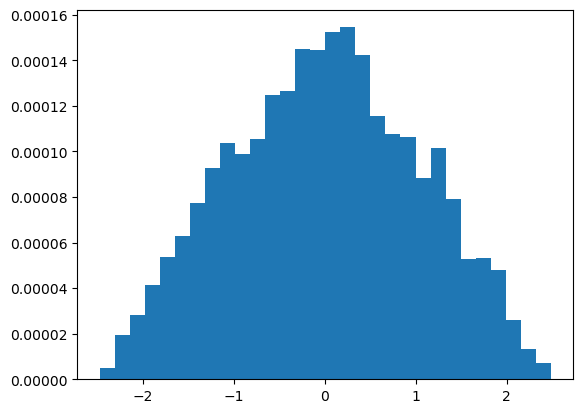

In [82]:
plt.figure()
plt.hist(df['rapidity'].to_numpy(), bins=30, weights=df['weight'].to_numpy())
plt.show()

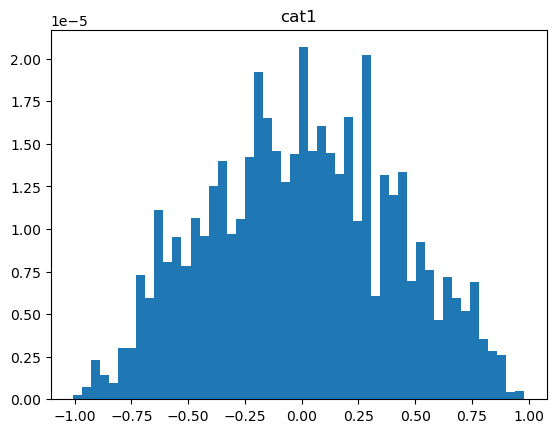

In [96]:
mask = (
            (df['lead_mvaID']>0.24) & (df['sublead_mvaID']>0.24)
            # & (((df['rapidity'] > 0.9) & (df['rapidity'] < 1.2)) | ((df['rapidity'] < -0.9) & (df['rapidity'] > -1.2)))
            & (df['sigma_m_over_m_corr_smeared_decorr'] < 0.0115)
            # & (df['sigma_m_over_m_corr_smeared_decorr'] > 0.0115) & (df['sigma_m_over_m_corr_smeared_decorr'] < 0.0175)
            # & (df['sigma_m_over_m_corr_smeared_decorr'] > 0.0175) & (df['sigma_m_over_m_corr_smeared_decorr'] < 0.0315)
)

plt.figure()
plt.hist(df['rapidity'][mask].to_numpy(), bins=50, weights=df['weight'][mask].to_numpy())
# plt.hist(df['pt'][mask].to_numpy(), bins=50, weights=df['weight'][mask].to_numpy())
# plt.hist(df['sigma_m_over_m_corr_smeared_decorr'][mask].to_numpy(), bins=50, weights=df['weight'][mask].to_numpy())
plt.title("cat1")
plt.show()